In [12]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [13]:
### SET UP FOR A THREE LEVEL SYSTEM
ground = Qobj([[1],[0],[0]])  
storage = Qobj([[0],[1],[0]]) 
excited = Qobj([[0],[0],[1]]) 

sigma_ge = Qobj([[0,0,0],[0,0,0],[1,0,0]])  # |e><g| (transition from g to e)
sigma_eg = Qobj([[0,0,1],[0,0,0],[0,0,0]])  # |g><e| (transition from e to g)

sigma_se = Qobj([[0,0,0],[0,0,0],[0,1,0]])  # |e><s| (transition from s to e)
sigma_es = Qobj([[0,0,0],[0,0,1],[0,0,0]])  # |s><e| (transition from e to s)

sigma_gs = Qobj([[0,0,0],[1,0,0],[0,0,0]])  # |s><g| (transition from g to s)
sigma_sg = Qobj([[0,1,0],[0,0,0],[0,0,0]])  # |g><s| (transition from s to g)

## Hamiltonian
The Hamiltonian for the three-level system is

$$ \hat{H} = g_{ge} (\hat{\textbf{a}}_{ge}(t)\hat{\sigma}_{ge}+ \hat{\textbf{a}}_{ge}^\dagger(t)\hat{\sigma}_{eg}) +
g_{se} (\hat{\textbf{a}}_{se}(t)\hat{\sigma}_{se} + \hat{\textbf{a}}_{se}^\dagger(t)\hat{\sigma}_{es})
$$

The $\hat{\textbf{a}}_{ge}(t)$ corresponds to the input pulse (signal), whereas $\hat{\textbf{a}}_{se}(t)$ corresponds to the control pulse we apply. Again, we seem to ultimately ignore the vacuum field after expectation valuing.  The couplings $g_{se}, g_{ge}$ should be determined by the medium (constants). We will denote $\beta(t)$ and $\alpha(t)$ as the expectation value of $\hat{\textbf{a}}_{se}(t)$ and  $\hat{\textbf{a}}_{ge}(t)$ respectively. After expectation valuing everything:

$$ \hat{H} = g_{ge} (\alpha(t)\hat{\sigma}_{ge}+ \alpha^\dagger(t)\hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) $$

Assuming the input signal is real,

$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) $$

## Decay Terms

The decay terms are now given by:
$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{C}{g_{ge}^*}\hat{\sigma}_{eg}, {g_{se}^*}\hat{\sigma}_{es}\end{bmatrix} $$


Lindblad has a factor of (C+1)/C



first term is from the bath that alpha comes from, second comes from a completely separate bath (diffuse, free space).
Would need a different factor for the se decay term but for now, make g_se small ~ 1/C * g_eg (typically cooperativity is not defined for the beta pulse)
g_eg is dependent on cooperativity so we could alternatively put the C on the Hamiltonian and first term decay, rather than 1/c on the second term of the decay



For the sake of simplicity, we will remove the es term as we don't want this type of decay ideally.
$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}\end{bmatrix} $$

This is different from the two-level system: our vacuum Rabi frequency is defined by $g$ but here, we have a constant vacuum Rabi frequency defined by $g_{se}$, for example. 

Note that the Lindblad term does not include a signal or coupling term: the signal does not affect the dynamics of the Hamiltonian. when you adiabatically eliminate the excited state, the effective Rabi frequency between gs state appears (why?). In our current simulation, there is no adiabatic elimination, so we do not include the signal in the Lindblad terms. After the adiabatic elimination, signal shows up in the Lindblad terms. 

Alpha may need a detuning term (e^{I delta t)) or Hamiltonian has additional delta dependence (shift excited state, sigma ee term)
Beta is causing detuning on eg, and this makes alpha out of resonance with the eg transition.

### Tests:

$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) $$

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, {g_{se}^*}\hat{\sigma}_{es}\end{bmatrix} $$

1. Set $\beta(t) = 0$.  Without dissipation, we expect the signal to simply spin up the atom slightly to the excited state. Storage state should be 0. With dissipation (only eg dissipation), it should behave as the typical TLS and decay. These two cases work.

2. Set $\beta(t)$ equal to the optimal case. Without dissipation, I'm not sure what to expect because this $\beta(t)$ is tailored to the case where there is dissipation. With dissipation (eg dissipation only), I'd expect the excited state probability to reach 0.01, same as the number of photons. 

We will observe in the three-level system that efficiencies don't work as well because of the AC stark shift - to correct this, detune frequencies of input light which corrects stark shift during the simulation (phase factor from h). We will pick up phase in the template if we don't account for stark shift (diff dressed state energy shift between the 2 ground states).

check cavity parameters of Gorshkov 

Let's continue with this for now as before and just simulate.

In [ ]:
T = 10 # total time (input pulse "duration")
N = 5000 # number of time steps

g_se = 1
g_ge = 1 # Set this to 0 to simulate TLS with constant coupling

mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse

# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    a = 0.1 # small amplitude
    return a*(gaussian(mu, sigma, t)) # + np.random.normal(0, sigma*0.01, 1)) # Gaussian input

time = np.linspace(0, T, N)
alpha = alpha_in(time) # input signal
print("Area of alpha:", integrate.simps(alpha**2, time))

Area of alpha: 0.00999999999999231


derivative of h = energy shift (could also have hamiltonian shift the energy LEVELS around)

### Optimal coupling $\beta(t)$

From Gorshkov's paper, the optimal control pulse shape to store the incoming signal $\alpha_{in}$: 

$$\beta(t)= -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^T{|\alpha_{in}(t)|^2 dt}}} \cdot
\text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(1+C)^2+\Delta^2} \right)$$


- $h(t, T) = \int_t^T |g_{se}\beta(t)|^2 dt$.  What is $T$? Seems to be pulse duration, which here we will simply treat as the end of time array. (integrated phaes accumulation due to AC stark shift. Note that this would become 0 if we rotated into an AC stark shifted frame). There will be discrete time steps in the Hamiltonian due to h(t) integrator. If we can make this more discontinuous at second order rather than first order, the simulation may scale better with time.
- $C$ is cavity cooperativity.
- $\gamma$ is decay rate (of the excited state?)
- $\Delta$ is the detuning of the Raman memory
- $T$ is the duration of the input pulse

We can rewrite this for the code as:

$$ \beta(t) = a \times b \times \text{exp} \left(\frac{i\Delta h(t, T)}{c}\right)$$
- $a = -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}}$
- $b = \frac{\alpha_{in}(t)}{\sqrt{\int_0^T{|\alpha_{in}(t)|^2dt}}}$
- $c = \gamma^2(1+C)^2+\Delta^2$

Note: could be interesting trying to simulate the Gorshkov Hamiltonian with its 50 terms. Also, when we are computing h, note that $|\beta(t)|^2$ will be $|a \cdot b|^2$.

In [ ]:
gamma = 1       # decay rate
C = 200           # cooperativity (higher = more efficient)
Delta = 100        # detuning

# Precompute prefactors (constants)
a = -(gamma*(1+C) - 1j*Delta) / np.sqrt(2*gamma*(1+C))
c = gamma**2*(1+C)**2 + Delta**2

# Compute b
b = [0]
for i in range(1, len(time)):
    integral_val = integrate.simps(abs(alpha[0:i])**2, time[0:i]) # integral (0 to t) of |alpha|^2
    if (integral_val == 0):
        b.append(0)
    else:      
        b.append(alpha[i] / (np.sqrt(integral_val)))
b = np.array(b)

In [16]:
# Returns the integral of |beta(t)|^2 from t[idx] to t[-1]
def get_h(beta_vals, idx, time):
    h_val = integrate.simps(np.abs(beta_vals[idx:-1])**2, time[idx:-1]) # Integrate beta from time[idx] to time[-1]
    return h_val

  0%|          | 0/4999 [00:00<?, ?it/s]

100%|██████████| 4999/4999 [00:01<00:00, 2597.04it/s]


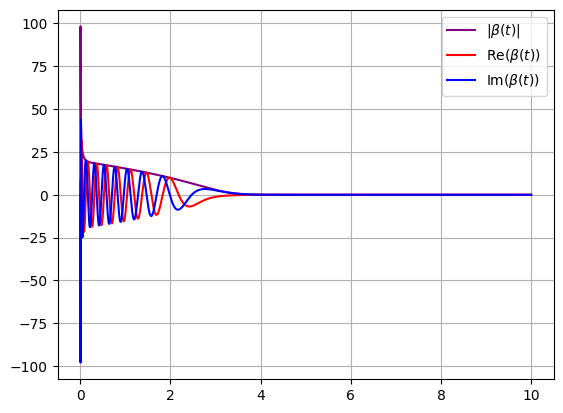

In [17]:
beta_vals = np.array([0])
h_vals = np.array([0])
for idx in tqdm(range(0, len(time)-1)):
    h = get_h(a*b, idx, time)
    if np.imag(h) != 0: print('Imaginary part detected')
    beta_vals = np.append(beta_vals, a*b[idx]*np.exp(1j*Delta*h/c))
    h_vals = np.append(h_vals, h)

def beta(t):
    #return 0
    if t == time[0]: return 0
    else:            return np.interp(t, time, beta_vals)  # Interpolate smoothed g values    
    
# Plot results
plt.plot(time, abs(beta_vals), color='purple', label=r'$|\beta(t)|$')
plt.plot(time, np.real(beta_vals), color='red', label=r'Re$(\beta(t))$')
plt.plot(time, np.imag(beta_vals), color='blue', label=r'Im$(\beta(t))$')
plt.grid()
plt.legend()

$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) $$

In [18]:
### ---------------------------- HAMILTONIAN ---------------------------------
H_signal = sigma_ge + sigma_eg
H_coupling = sigma_se
H_coupling_dag = sigma_es

def H_signal_coeff(t, args): 
    return g_ge * alpha_in(t) 

def H_coupling_coeff(t, args):
    return g_se * beta(t)

def H_coupling_dag_coeff(t, args):
    return g_se * np.conjugate(beta(t))

H = [[H_signal, H_signal_coeff], [H_coupling, H_coupling_coeff], [H_coupling_dag, H_coupling_dag_coeff]] # Final Hamiltonian 

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -{g_{se}^*} \hat{\sigma}_{es} \end{bmatrix} $$


In [19]:
# ------------------DISSIPATION OPERATORES (collapse operators)-----------------
def col_coeff_es(t, args): 
    return -np.conjugate(g_se) 

def col_coeff_eg(t, args): 
    return -np.conjugate(g_ge) 

c_op_list = [] # No dissipation
#c_op_list = [[sigma_eg, col_coeff_eg]]  # time-dependent collapse term for TLS test
#c_op_list = [[sigma_es, col_coeff_es], [sigma_eg, col_coeff_eg]]  # time-dependent collapse term

### SIMULATE: starting from the ground state, solve Schrodinger equation
psi0 = ground # |g> 
result = mesolve(H, psi0, time, c_op_list) 

In [20]:
###--------------------- RESULTS ---------------------------
prob_g = [] # probability of finding state in |g>
prob_s = [] # probability of finding state in |s>
prob_e = [] # probability of finding state in |e>

S = [] # expectation value of |g><s|

for i in range(0, len(result.states)):
    # No dissipation (result outputs states) 
    p_g, p_s, p_e = abs(result.states[i][0])**2, abs(result.states[i][1])**2, abs(result.states[i][2])**2
    
    # With dissipation (result outputs density operators)
    #p_g, p_s, p_e = result.states[i][0][0], result.states[i][1][1], result.states[i][2][2]
    
    prob_g = np.append(prob_g, p_g)
    prob_s = np.append(prob_s, p_s)
    prob_e = np.append(prob_e, p_e)

    S = np.append(S, expect(sigma_gs, result.states[i]))

S_ideal = []

Final |s> probability:  0.06045778034876272


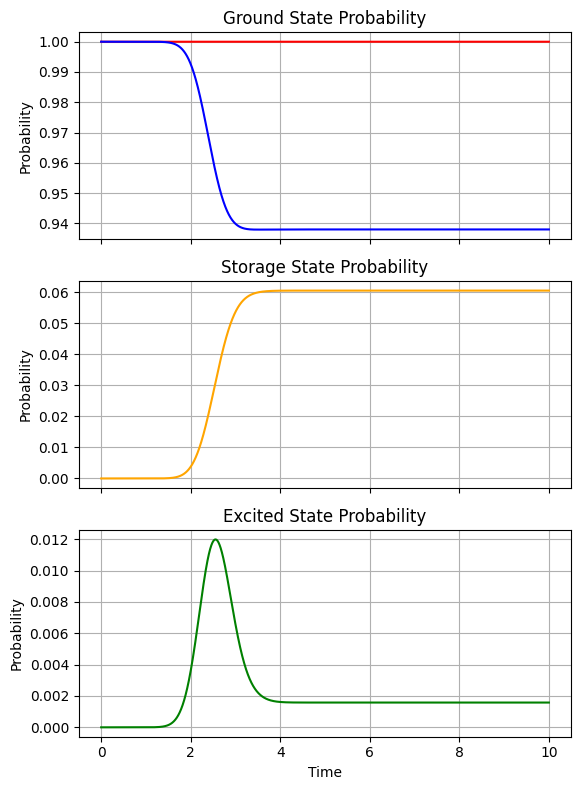

In [21]:
print('Final |s> probability: ', abs(prob_s[-1]))
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# Sanity checks
axs[0].plot(time, prob_g+prob_e+prob_s, color='red')
axs[0].plot(time, prob_g, color='blue')
axs[0].set_ylabel('Probability')
axs[0].set_title('Ground State Probability')
axs[0].grid()

axs[1].plot(time, prob_s, color='orange')
axs[1].set_ylabel('Probability')
axs[1].set_title('Storage State Probability')
axs[1].grid()

axs[2].plot(time, prob_e, color='green')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Probability')
axs[2].set_title('Excited State Probability')
axs[2].grid()
plt.tight_layout()

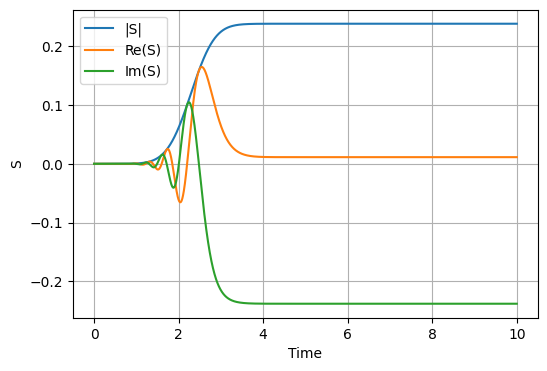

In [22]:
plt.figure(figsize=(6,4))
plt.plot(time, abs(S), label='|S|')
plt.plot(time, np.real(S), label='Re(S)')
plt.plot(time, np.imag(S), label='Im(S)')
plt.xlabel('Time'); plt.ylabel('S')
plt.legend(); plt.grid()